Epoch 1/30 | Val Acc: 0.7027
Epoch 2/30 | Val Acc: 0.8000
Epoch 3/30 | Val Acc: 0.8054
Epoch 4/30 | Val Acc: 0.8378
Epoch 5/30 | Val Acc: 0.8324
Epoch 6/30 | Val Acc: 0.8000
Epoch 7/30 | Val Acc: 0.7946
Epoch 8/30 | Val Acc: 0.8162
Epoch 9/30 | Val Acc: 0.8108
Epoch 10/30 | Val Acc: 0.8378
Epoch 11/30 | Val Acc: 0.8216
Epoch 12/30 | Val Acc: 0.8054
Epoch 13/30 | Val Acc: 0.8432
Epoch 14/30 | Val Acc: 0.8216
Epoch 15/30 | Val Acc: 0.8162
Epoch 16/30 | Val Acc: 0.8108
Epoch 17/30 | Val Acc: 0.8216
Epoch 18/30 | Val Acc: 0.8162
Epoch 19/30 | Val Acc: 0.7946
Epoch 20/30 | Val Acc: 0.7892
Epoch 21/30 | Val Acc: 0.7784
Epoch 22/30 | Val Acc: 0.7946
Epoch 23/30 | Val Acc: 0.8324
Epoch 24/30 | Val Acc: 0.8270
Epoch 25/30 | Val Acc: 0.8216
Epoch 26/30 | Val Acc: 0.8162
Epoch 27/30 | Val Acc: 0.8054
Epoch 28/30 | Val Acc: 0.8108
Epoch 29/30 | Val Acc: 0.8541
Epoch 30/30 | Val Acc: 0.8000


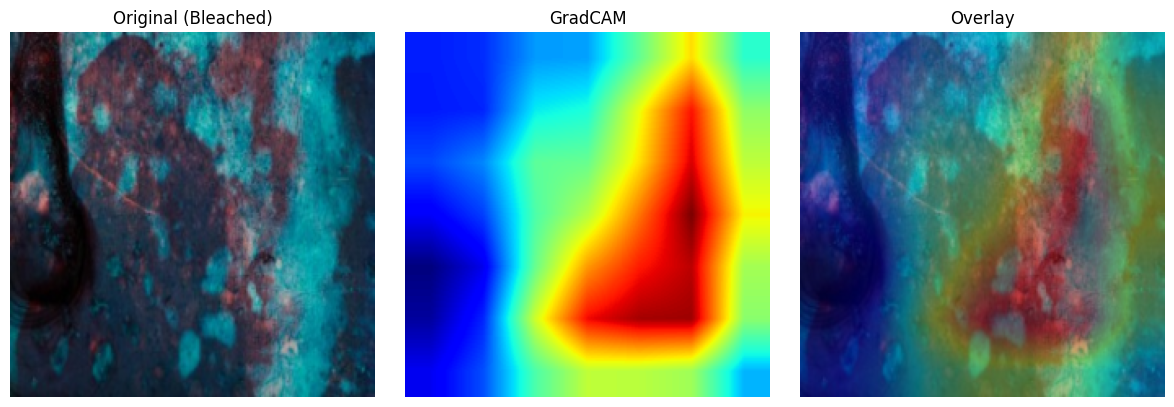

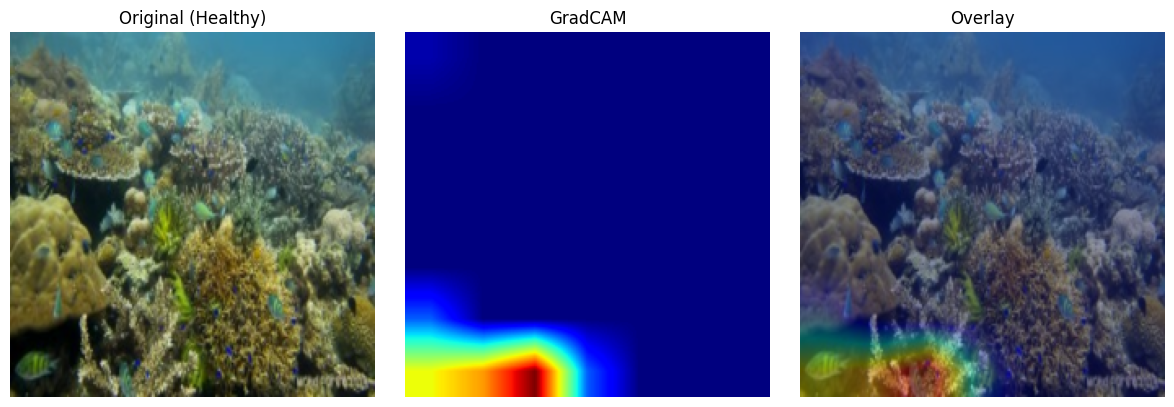

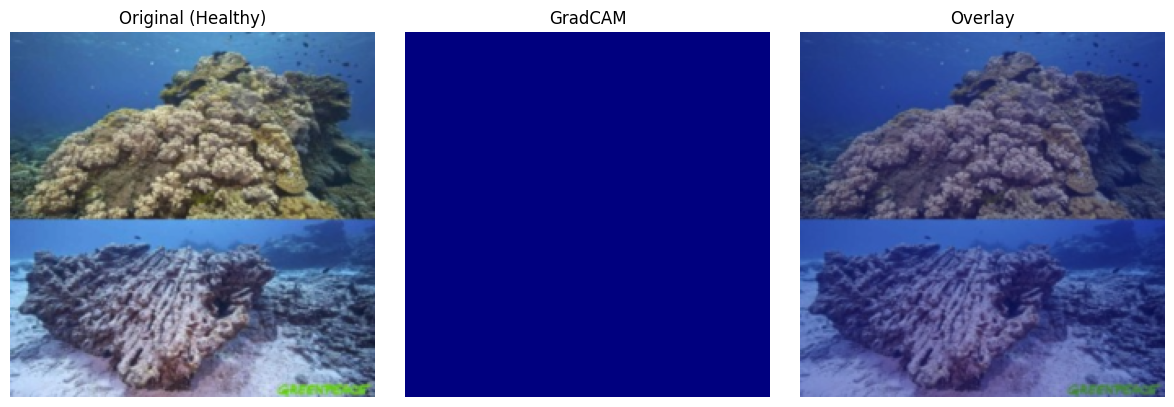


CNN
              precision    recall  f1-score   support

     Healthy       0.83      0.88      0.85        88
    Bleached       0.88      0.84      0.86        97

    accuracy                           0.85       185
   macro avg       0.85      0.86      0.85       185
weighted avg       0.86      0.85      0.85       185



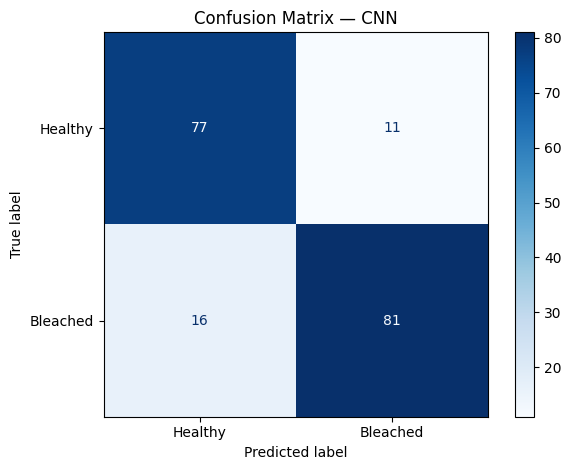


XGBoost
              precision    recall  f1-score   support

     Healthy       0.69      0.69      0.69        88
    Bleached       0.72      0.71      0.72        97

    accuracy                           0.70       185
   macro avg       0.70      0.70      0.70       185
weighted avg       0.70      0.70      0.70       185



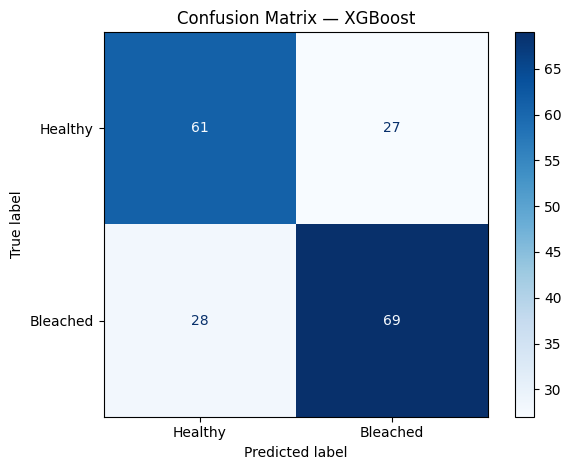


Fusion
              precision    recall  f1-score   support

     Healthy       0.82      0.86      0.84        88
    Bleached       0.87      0.82      0.85        97

    accuracy                           0.84       185
   macro avg       0.84      0.84      0.84       185
weighted avg       0.84      0.84      0.84       185



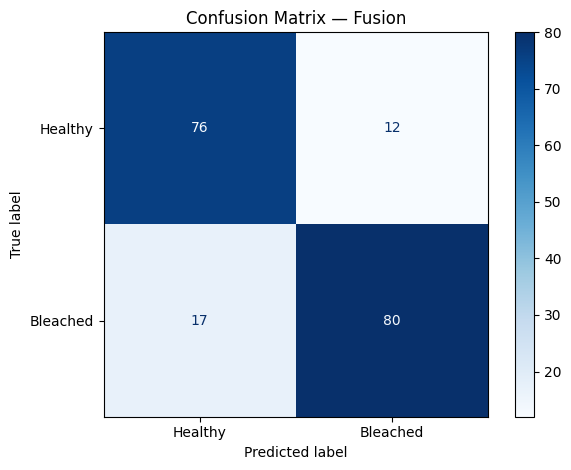

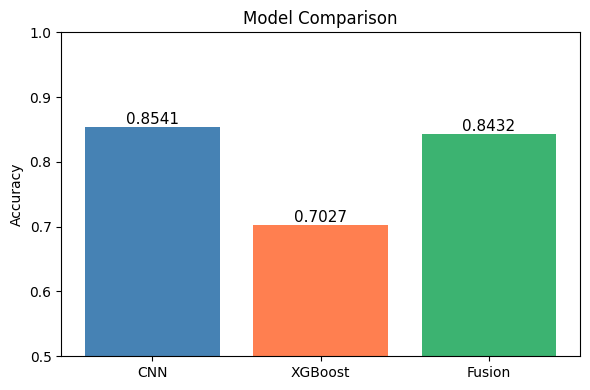

In [4]:
import cv2, os, torch, numpy as np, matplotlib.pyplot as plt
import torchvision.models as models
import torchvision.transforms as T
import torch.nn as nn
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay
from xgboost import XGBClassifier

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

train_transform = T.Compose([
    T.ToPILImage(), T.Resize((224, 224)), T.RandomHorizontalFlip(),
    T.ToTensor(), T.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
])
val_transform = T.Compose([
    T.ToPILImage(), T.Resize((224, 224)),
    T.ToTensor(), T.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
])


def load_images(base_dir):
    images, labels = [], []
    for folder, label in [("healthy", 0), ("bleached", 1)]:
        path = os.path.join(base_dir, folder)
        for fname in os.listdir(path):
            if fname.lower().endswith((".jpg", ".jpeg", ".png")):
                img = cv2.imread(os.path.join(path, fname))
                images.append(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
                labels.append(label)
    return images, labels


def build_model():
    model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
    for name, param in model.named_parameters():
        if "layer4" not in name and "fc" not in name:
            param.requires_grad = False
    model.fc = nn.Linear(model.fc.in_features, 1)
    return model.to(DEVICE)


def train_model(model, train_loader, val_loader, epochs=30):
    loss_fn   = nn.BCEWithLogitsLoss()
    optimizer = torch.optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=3e-4)
    best_acc  = 0.0

    for epoch in range(epochs):
        model.train()
        for imgs, labels in train_loader:
            imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
            optimizer.zero_grad()
            loss_fn(model(imgs).squeeze(1), labels).backward()
            optimizer.step()

        model.eval()
        correct = total = 0
        with torch.no_grad():
            for imgs, labels in val_loader:
                imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
                preds = (torch.sigmoid(model(imgs).squeeze(1)) > 0.5).float()
                correct += (preds == labels).sum().item()
                total   += labels.size(0)

        acc = correct / total
        print(f"Epoch {epoch+1}/{epochs} | Val Acc: {acc:.4f}")
        if acc > best_acc:
            best_acc = acc
            torch.save(model.state_dict(), "best_model.pt")

    model.load_state_dict(torch.load("best_model.pt"))
    return model


def get_cnn_probs(model, val_tensors):
    model.eval()
    with torch.no_grad():
        return np.array([torch.sigmoid(model(t.unsqueeze(0).to(DEVICE))).item() for t in val_tensors])


def get_spectral_features(img):
    img = img.astype(np.float32)
    R, G, B = img[..., 0], img[..., 1], img[..., 2]
    ExG, rCBI, NGRDI = 2*G-R-B, (R-B)/(R+B+1e-5), (G-R)/(G+R+1e-5)
    return [ExG.mean(), ExG.std(), rCBI.mean(), rCBI.std(), NGRDI.mean(), NGRDI.std()]


def get_gradcam(model, img_tensor):
    saved = {}
    h1 = model.layer4[-1].register_forward_hook(lambda m,i,o: saved.update({"acts": o.detach()}))
    h2 = model.layer4[-1].register_full_backward_hook(lambda m,gi,go: saved.update({"grads": go[0].detach()}))
    model(img_tensor.unsqueeze(0).to(DEVICE)).backward()
    h1.remove(); h2.remove()
    acts, grads = saved["acts"][0].cpu().numpy(), saved["grads"][0].cpu().numpy()
    cam = (grads.mean(axis=(1,2))[:, None, None] * acts).sum(axis=0)
    cam = np.maximum(cam, 0)
    cam = (cam - cam.min()) / (cam.max() + 1e-8)
    return cv2.resize(cam, (224, 224))


def show_gradcam(model, img_tensor, label, idx):
    cam  = get_gradcam(model, img_tensor)
    orig = np.clip(img_tensor.permute(1,2,0).numpy().astype(np.float64) * [0.229,0.224,0.225] + [0.485,0.456,0.406], 0, 1)
    heat = cv2.cvtColor(cv2.applyColorMap(np.uint8(255*cam), cv2.COLORMAP_JET), cv2.COLOR_BGR2RGB) / 255.0

    plt.figure(figsize=(12, 4))
    for i, (img, title) in enumerate(zip(
        [orig, cam, 0.65*orig + 0.35*heat],
        [f"Original ({'Bleached' if label==1 else 'Healthy'})", "GradCAM", "Overlay"]
    )):
        plt.subplot(1,3,i+1); plt.imshow(img, cmap="jet" if i==1 else None)
        plt.title(title); plt.axis("off")
    plt.tight_layout()
    plt.savefig(f"gradcam_{idx}.png", dpi=150)
    plt.show()


def evaluate(name, y_true, y_pred):
    print(f"\n{name}\n" + "="*40)
    print(classification_report(y_true, y_pred, target_names=["Healthy", "Bleached"]))
    disp = ConfusionMatrixDisplay(confusion_matrix(y_true, y_pred), display_labels=["Healthy", "Bleached"])
    disp.plot(cmap="Blues")
    plt.title(f"Confusion Matrix — {name}")
    plt.tight_layout()
    plt.savefig(f"cm_{name}.png", dpi=150)
    plt.show()


BASE = "../dataset"

images, labels = load_images(BASE)
X_train_imgs, X_val_imgs, y_train, y_val = train_test_split(images, labels, test_size=0.2, random_state=42, stratify=labels)

train_tensors = [train_transform(img) for img in X_train_imgs]
val_tensors   = [val_transform(img)   for img in X_val_imgs]

train_loader = torch.utils.data.DataLoader(
    list(zip(train_tensors, [torch.tensor(l, dtype=torch.float32) for l in y_train])), batch_size=16, shuffle=True)
val_loader = torch.utils.data.DataLoader(
    list(zip(val_tensors, [torch.tensor(l, dtype=torch.float32) for l in y_val])), batch_size=16)

model = build_model()
model = train_model(model, train_loader, val_loader)

for i in [0, 5, 10]:
    show_gradcam(model, val_tensors[i], y_val[i], i)

cnn_probs = get_cnn_probs(model, val_tensors)
cnn_preds = (cnn_probs > 0.5).astype(int)

X_feats = np.array([get_spectral_features(img) for img in images])
Xt, Xv, yt, yv = train_test_split(X_feats, labels, test_size=0.2, random_state=42, stratify=labels)
xgb = XGBClassifier(n_estimators=200, max_depth=4, learning_rate=0.05, eval_metric="logloss")
xgb.fit(Xt, yt, eval_set=[(Xv, yv)], verbose=False)
xgb_probs = xgb.predict_proba(Xv)[:, 1]
xgb_preds = (xgb_probs > 0.5).astype(int)

fused_probs = 0.6 * cnn_probs + 0.4 * xgb_probs
fused_preds = (fused_probs > 0.5).astype(int)

y_val_arr = np.array(y_val)
evaluate("CNN",     y_val_arr, cnn_preds)
evaluate("XGBoost", y_val_arr, xgb_preds)
evaluate("Fusion",  y_val_arr, fused_preds)

names = ["CNN", "XGBoost", "Fusion"]
accs  = [(cnn_preds==y_val_arr).mean(), (xgb_preds==y_val_arr).mean(), (fused_preds==y_val_arr).mean()]
plt.figure(figsize=(6, 4))
bars = plt.bar(names, accs, color=["steelblue", "coral", "mediumseagreen"])
plt.ylim(0.5, 1.0)
plt.ylabel("Accuracy")
plt.title("Model Comparison")
for bar, acc in zip(bars, accs):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005, f"{acc:.4f}", ha="center", fontsize=11)
plt.tight_layout()
plt.savefig("model_comparison.png", dpi=150)
plt.show()